# Assignment 2



In [29]:
# imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import make_scorer, fbeta_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn import svm, datasets
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
sns.set_theme(style="whitegrid")

In [12]:
# import datasets
train_df = pd.read_csv("./cleaned_train.csv")
val_df = pd.read_csv("./cleaned_validation.csv")
test_df = pd.read_csv("./cleaned_test.csv")


Although for assignment 1, I separated the dataset into separate datasets for training and validation as well as testing, I recondiered and decided to adopt cross validation in order to give a more stable estimate of model performance, due to the relatively small sample size.

In [26]:
train_df = pd.read_csv("./cleaned_train.csv")
val_df = pd.read_csv("./cleaned_validation.csv")

target_col = "Risk Level"
risk_map = {"High": 1, "Low": 0}

for df in [train_df, val_df]:
    df[target_col] = df[target_col].map(risk_map)

feature_cols = [c for c in train_df.columns if c != target_col]

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_val = val_df[feature_cols]
y_val = val_df[target_col]

X_trainval = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
y_trainval = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)

print(y_trainval.value_counts(normalize=True))
print(X_trainval.shape)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Risk Level
0    0.603226
1    0.396774
Name: proportion, dtype: float64
(930, 11)


As above, the merged training + validation dataset has a similar stratification of risk level to the training set.

## Scoring/Evaluation

F2 is a very important metric for evaluating the models, and will be used accross the models, so is defined here before the models.

In [27]:
# beta = 2 -> F2 (not F1 score)
# pos_label=1 means High Risk = 1 is the positive value
f2_scorer = make_scorer(fbeta_score, beta=2, pos_label=1)

# Naive Prediction

Just for the sake of comparision, as mentioned in Assignment 1, simply predicting everyone as low risk should result in an accuracy level of 60%. Here the confusion matrix is constructed to test that assumption

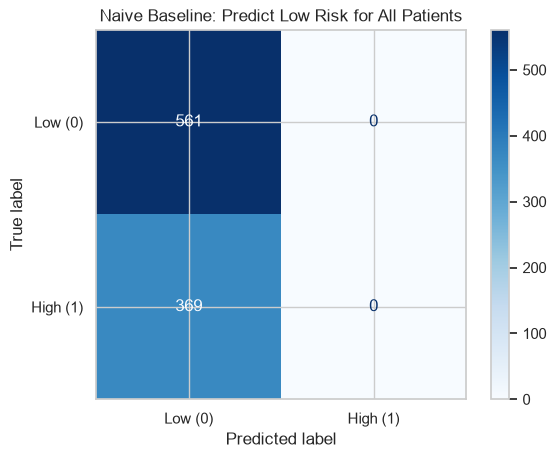

Naive baseline F2 score: 0.0000


In [28]:
y_naive_pred = np.zeros_like(y_trainval)

cm = confusion_matrix(y_trainval, y_naive_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low (0)', 'High (1)'])
disp.plot(cmap='Blues')
plt.title('Naive Baseline: Predict Low Risk for All Patients')
plt.show()

naive_f2 = fbeta_score(y_trainval, y_naive_pred, beta=2, pos_label=1)
print(f"Naive baseline F2 score: {naive_f2:.4f}")

So any F2 score above 0 will be an improvement, and can be assessed for significance.

## Baseline Model

This is a logistic regression model. In contrast to the tree based models, here scaling is vitally important with different features having very different scales. The pipeline is as follows: raw data -> scaling -> logistic regression -> predictions.

Note in the parameter grid below, the clf__penalty choses to use lasso first and then ridge as there is some moderate multicolinearity (e.g. Mental Health and Previous Complications and/or Preexisting Diabetes). If Mental Health's contribution really is mostly redundant once the other two are accounted for, l1 regularisation may zero out its coefficient entirely during fitting, keeping only features that add genuinely independent predictive value.

In [32]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(solver='liblinear', max_iter=1000, random_state=42))
])

parameter_grid = {
    'clf__C': [0.01, 0.1, 1, 10, 100], # controls regularisation strength, smaller means simpler model
    'clf__penalty': ['l1', 'l2'], # l1 = lasso, l2 = ridge
    'clf__class_weight': ['balanced', None]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=parameter_grid,
    scoring=f2_scorer,
    cv=cv,
    n_jobs=-1,
    refit=True,
    return_train_score=True
)

grid_search.fit(X_trainval, y_trainval)

/Users/aislinglangston/Documents/CFG_2026/CFG +Masters/Maternal_health_assignment/tf_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/aislinglangston/Documents/CFG_2026/CFG +Masters/Maternal_health_assignment/tf_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/aislinglangston/Documents/CFG_2026/CFG +Masters/Maternal_health_assignment/tf_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWar

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...liblinear'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'clf__C': [0.01, 0.1, ...], 'clf__class_weight': ['balanced', None], 'clf__penalty': ['l1', 'l2']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","make_scorer(f..., pos_label=1)"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will o

In [33]:
best_model = grid_search.best_estimator_
coefs = best_model.named_steps['clf'].coef_[0]
feature_names = X_trainval.columns

coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': coefs})
coef_df = coef_df.sort_values('coefficient', key=abs, ascending=False)
print(coef_df)

                   feature  coefficient
7     Preexisting Diabetes     1.582736
8     Gestational Diabetes     1.231714
9            Mental Health     0.883697
3                       BS     0.732465
10              Heart Rate     0.709093
6   Previous Complications     0.691067
5                      BMI     0.553082
2                Diastolic     0.426831
0                      Age    -0.389448
4                Body Temp     0.320348
1              Systolic BP     0.316451


The top three features identified in this logistic regression model are Preexisting Diabetes, Gestational Diabetes, and Mental Health. The first two were expected from the exploratory analysis, but Mental Health was not so anticipated. 

In [34]:
print("Best parameters:", grid_search.best_params_)
print("Best CV score (F2):", grid_search.best_score_)

Best parameters: {'clf__C': 0.1, 'clf__class_weight': 'balanced', 'clf__penalty': 'l2'}
Best CV score (F2): 0.9696185058306501


This model appears to have a very convincing F2 score of 0.09696. While this implicitly suggests a strong predictive power, it strongly suggests that this logistic regression model has found the rule proposed within assignment 1: that risk level was determined by a small number of features.

In [35]:
results_df = pd.DataFrame(grid_search.cv_results_)
results_df = results_df.sort_values('mean_test_score', ascending=False)

results_df[['params', 'mean_test_score', 'std_test_score', 'mean_train_score']].head(10)

,params,mean_test_score,std_test_score,mean_train_score
5,"{'clf__C': 0.1, 'clf__class_weight': 'balanced...",0.969619,0.011255,0.971772
8,"{'clf__C': 1, 'clf__class_weight': 'balanced',...",0.969091,0.011021,0.975166
17,"{'clf__C': 100, 'clf__class_weight': 'balanced...",0.969088,0.012408,0.975150
16,"{'clf__C': 100, 'clf__class_weight': 'balanced...",0.969088,0.012408,0.975150
12,"{'clf__C': 10, 'clf__class_weight': 'balanced'...",0.969088,0.012408,0.974606
13,"{'clf__C': 10, 'clf__class_weight': 'balanced'...",0.969088,0.012408,0.975562
9,"{'clf__C': 1, 'clf__class_weight': 'balanced',...",0.968566,0.011808,0.974888
4,"{'clf__C': 0.1, 'clf__class_weight': 'balanced...",0.967026,0.011265,0.968851
7,"{'clf__C': 0.1, 'clf__class_weight': None, 'cl...",0.962233,0.022821,0.964924
6,"{'clf__C': 0.1, 'clf__class_weight': None, 'cl...",0.959797,0.018585,0.964817
